#05 - Baseline modeling
##Obiettivo del notebook
Costruire primi modelli semplici per avere una baseline di confronto.

#1. Caricamento dati e distinzione tra features categoriche/numeriche
Carichiamo i due file principali (values e labels) e separiamo le colonne in base al loro tipo

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

train_values = pd.read_csv('../data/raw/train_values.csv')
train_labels = pd.read_csv('../data/raw/train_labels.csv')

features = train_values.drop(columns=['building_id'])
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

#2. Preprocessing
Qui trasformiamo i dati grezzi in un formato che può essere elaborato dai modelli.

* **One-Hot Encoding**: trasformiamo le variabili categoriche in numeri che i modelli possono elaborare

* **Train-Test Split**: Dividiamo il dataset in due parti (80% training, 20% validation). Questo ci permette di testare il modello su dati che non ha mai visto, simulando la sfida finale

* **Scaling**: questo è vitale per la Logistic Regression, che altrimenti darebbe troppa importanza alle variabili con numeri grandi




In [16]:
# One-hot encoding per le variabili categoriche
X = pd.get_dummies(train_values.drop(columns=['building_id']), columns=categorical_cols)
y = train_labels['damage_grade']

# Split 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Scaling è obbligatorio per la Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#3. Inizializzazione dei modelli

In [17]:
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='multinomial'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42)
}

#4. Training e Evaluation
Per ogni modello:

* Lo addestriamo sui dati di training

* Gli chiediamo di fare predizioni sui dati di validazione

* Calcoliamo la Micro-F1 Score, generiamo il Classification Report  e la Confusion Matrix


==================== DUMMY CLASSIFIER ====================
Micro-F1 Score: 0.5689

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      5025
           2       0.57      1.00      0.73     29652
           3       0.00      0.00      0.00     17444

    accuracy                           0.57     52121
   macro avg       0.19      0.33      0.24     52121
weighted avg       0.32      0.57      0.41     52121



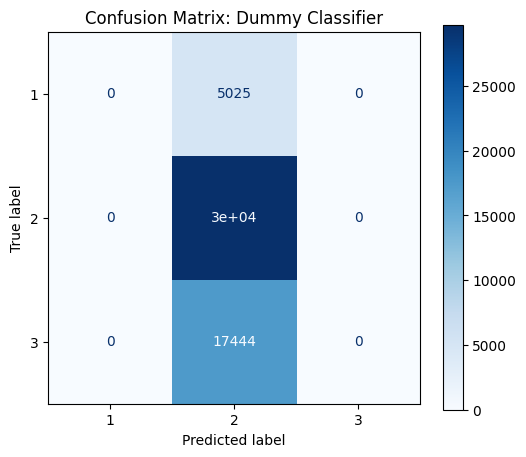


==================== LOGISTIC REGRESSION ====================
Micro-F1 Score: 0.5921

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.29      0.39      5025
           2       0.60      0.87      0.71     29652
           3       0.55      0.20      0.29     17444

    accuracy                           0.59     52121
   macro avg       0.57      0.46      0.46     52121
weighted avg       0.58      0.59      0.54     52121



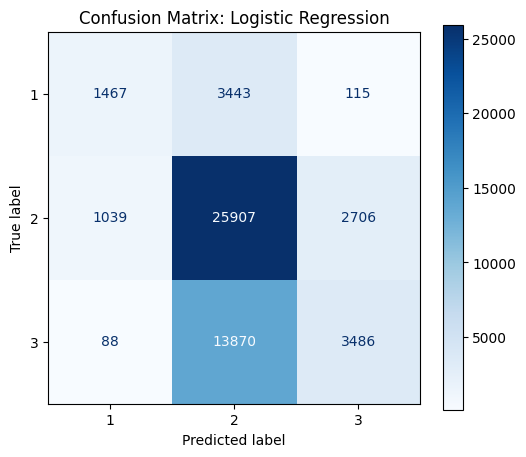


==================== DECISION TREE ====================
Micro-F1 Score: 0.6430

Classification Report:
              precision    recall  f1-score   support

           1       0.69      0.18      0.28      5025
           2       0.63      0.93      0.75     29652
           3       0.74      0.30      0.42     17444

    accuracy                           0.64     52121
   macro avg       0.69      0.47      0.48     52121
weighted avg       0.67      0.64      0.59     52121



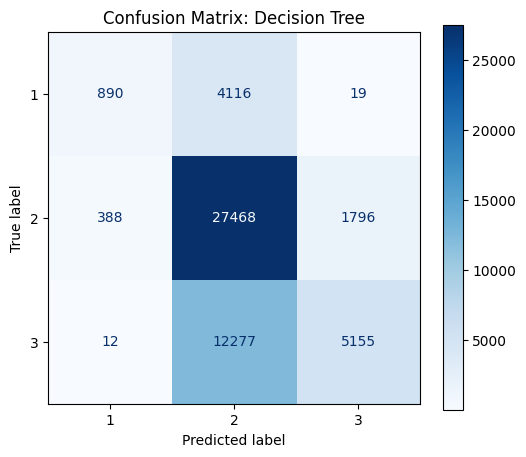

In [18]:
baseline_results = []

for name, model in models.items():
    print(f"\n{'='*20} {name.upper()} {'='*20}")

    # Usiamo i dati scalati solo per la Logistic Regression
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

    # 1. Micro-F1 Score
    score = f1_score(y_val, y_pred, average='micro')
    baseline_results.append({"Model": name, "Micro-F1": score})
    print(f"Micro-F1 Score: {score:.4f}")

    # 2. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    # 3. Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues', ax=ax)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

#5. Tabella di comparazione finale

In [19]:
summary_df = pd.DataFrame(baseline_results).sort_values(by="Micro-F1", ascending=False)
print("\n" + "="*20 + " SUMMARY TABLE " + "="*20)
print(summary_df)


==================== SUMMARY TABLE ====================
                 Model  Micro-F1
2        Decision Tree  0.642985
1  Logistic Regression  0.592084
0     Dummy Classifier  0.568907


#6. Conclusioni
##1. Il "Punto Zero": Dummy Classifier (0.5689)

* Il Dummy Classifier ci dice che se scommettessimo sempre sul Grado 2 (il più frequente), avremmo ragione nel 56.89% dei casi

* Qualsiasi modello "serio" deve fare sensibilmente meglio di 0.57 per essere considerato utile

##2. Logistic Regression (0.5921)

* La Logistic Regression migliora il Dummy di poco (+2.3%)

* Il modello lineare fatica a mappare la complessità dei dati geografici e strutturali

* Dal report la recall per il grado 3 è molto bassa (0.20). Significa che la Logistic Regression "si fida poco" a predire distruzioni totali e preferisce restare cauta sul grado 2

##3. Decision Tree (0.6430)

* Il Decision Tree semplice è il vincitore (+7.4% rispetto al Dummy)

* Questo conferma che il problema è non lineare

* Ha la precisione più alta sul grado 1 (0.69) e sul grado 3 (0.74).